<a href="https://colab.research.google.com/github/Vishal-Mungal/NNDLPRACTICAL/blob/main/NNDLPr6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.2563
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1753
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1057
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0897
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0874
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0867
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0861
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0857
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0853
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0851
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0848
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0846
Epoch 13/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0844
Epoch 14/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0842
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0841
Epoc

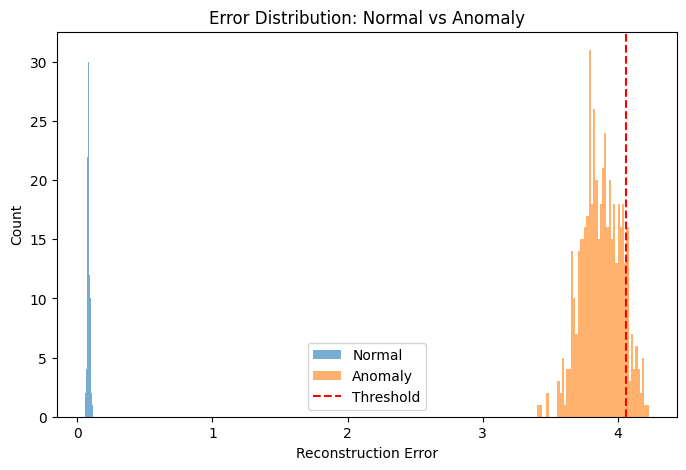

In [14]:
# STEP 1: Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# STEP 2: Synthetic dataset
X_normal = np.random.rand(500, 20, 3)
y_normal = np.zeros(500)

X_anomaly = np.random.rand(500, 20, 3) + 2.0
y_anomaly = np.ones(500)

X = np.concatenate([X_normal, X_anomaly], axis=0)
y = np.concatenate([y_normal, y_anomaly], axis=0)

# STEP 3: Autoencoder
inputs = Input(shape=(20, 3))
encoded = LSTM(16)(inputs)
decoded = RepeatVector(20)(encoded)
decoded = LSTM(3, return_sequences=True)(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# STEP 4: Train on normal data
history = autoencoder.fit(X_normal, X_normal, epochs=20, batch_size=32, verbose=1)

# STEP 5: Reconstruction error
X_pred = autoencoder.predict(X)
errors = np.mean(np.square(X - X_pred), axis=(1,2))

# STEP 6: Threshold
threshold = np.percentile(errors, 95)
y_pred = (errors > threshold).astype(int)

# STEP 7: Evaluation outputs
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))

# STEP 8: Visualize errors
plt.figure(figsize=(8,5))
plt.hist(errors[y==0], bins=50, alpha=0.6, label="Normal")
plt.hist(errors[y==1], bins=50, alpha=0.6, label="Anomaly")
plt.axvline(threshold, color='red', linestyle='--', label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.legend()
plt.title("Error Distribution: Normal vs Anomaly")
plt.show()